In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem as HS, PlotStyler

In [2]:
hs = HS(model="henon heiles")

In [3]:
num_ic = 200
dof = 2
E = 1 / 8
x, y = 0, -0.2
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)
q = [x, y]
p = [px, py]
num_intersections = 10000
total_time = 1e5

In [4]:
angles, ps = hs.CLV_angles(q, p, total_time,
                                                  subspaces=[([0, 1, 2], [3]), ([0], [1, 2, 3]), ([0, 1], [2, 3])],
                                                  pairs=(0, 3),
                                                  warmup_time=1e4,
                                                  tail_time=1e4,
                                                  poincare_section=True,)

Text(0, 0.5, '$p_y$')

<Figure size 640x480 with 0 Axes>

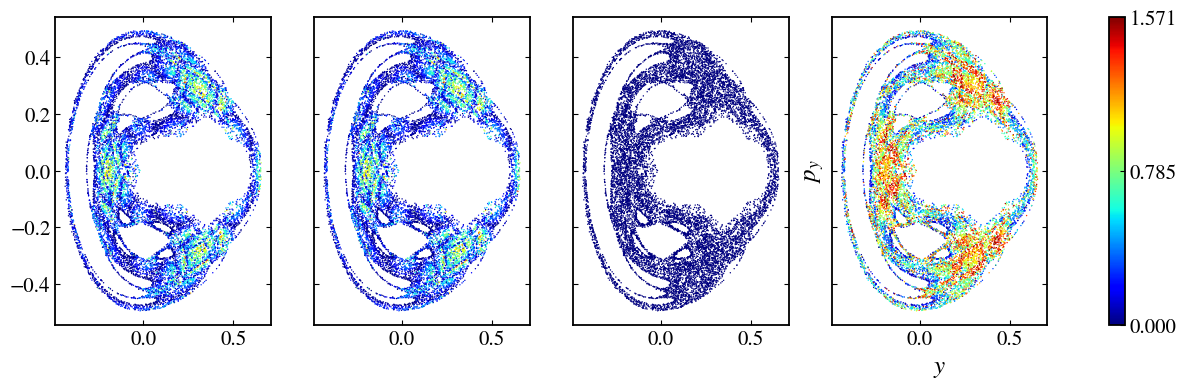

In [5]:
plot_styler = PlotStyler(fontsize=18, markersize=0.5, markeredgewidth=0)
plot_styler.apply_style()

fig, ax = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(16, 4))

for i in range(4):
    hm = ax[i].scatter(ps[:, 2], ps[:, 4], c=angles[:, i], cmap="jet", vmin=0, vmax=np.pi/2, edgecolor="none", s=1)
plt.colorbar(hm, ax=ax, ticks=[0, np.pi/4, np.pi/2])
plt.xlabel("$y$")
plt.ylabel("$p_y$")

(0.0, 1.5707963267948966)

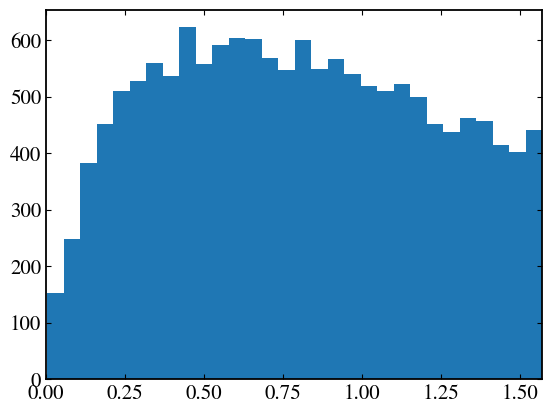

In [6]:
plt.hist(angles[:, -1], bins=30);
plt.xlim(0, np.pi/2)

In [7]:
%%time
_ = hs.covariant_lyapunov_vectors_angles(q, p, total_time, pairs=(0, 3))

AttributeError: 'HamiltonianSystem' object has no attribute 'covariant_lyapunov_vectors_angles'

In [8]:
%%time
_ = hs.covariant_lyapunov_vectors_angles(q, p, total_time, subspaces=[([0], [3])])

AttributeError: 'HamiltonianSystem' object has no attribute 'covariant_lyapunov_vectors_angles'